# Exploratory Data Analysis — Melbourne Rent Panel

**Research question:** What is the effect of a suburb's rental vacancy rate on subsequent rent growth in Melbourne?

**Data:** Suburb-quarter panel of 110 Melbourne suburbs, 2018 Q1 – 2025 Q3 (3,410 observations).  
**Source:** Victorian Government DFFH — moving annual median weekly rents by suburb, via data.vic.gov.au.

**Note on scope:** The research design requires suburb-level vacancy rate data from SQM Research as the key explanatory variable. This data could not be obtained due to access restrictions. The EDA below therefore focuses on the **dependent variable side** of the analysis — rent levels and rent growth — to understand the data characteristics, distributional properties, and regional patterns that will inform future modelling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv("../data/clean/suburb_quarter_panel.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Suburbs: {df['suburb'].nunique()}")
print(f"Regions: {df['region'].nunique()}")
print(f"Quarters: {df['quarter'].nunique()} ({df['quarter'].min()} to {df['quarter'].max()})")

Loaded: 3410 rows, 6 columns
Suburbs: 110
Regions: 9
Quarters: 31 (2018Q1 to 2025Q3)


In [2]:
df.head(10)

,region,suburb,quarter,median_rent,rent_growth,lag_median_rent
0,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2018Q1,550,NaN,NaN
1,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2018Q2,560,1.818182,550.0
2,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2018Q3,570,1.785714,560.0
3,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2018Q4,570,0.000000,570.0
4,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2019Q1,552,-3.157895,570.0
5,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2019Q2,560,1.449275,552.0
6,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2019Q3,565,0.892857,560.0
7,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2019Q4,595,5.309735,565.0
8,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2020Q1,600,0.840336,595.0
9,Inner Melbourne,Albert Park-Middle Park-West St Kilda,2020Q2,580,-3.333333,600.0


In [3]:
df.dtypes

region                 str
suburb                 str
quarter                str
median_rent          int64
rent_growth        float64
lag_median_rent    float64
dtype: object

## 1. Summary Statistics

We start by examining the numeric variables using `describe()` to understand their central tendency, spread, and range.

In [4]:
df[["median_rent", "rent_growth", "lag_median_rent"]].describe().round(2)

,median_rent,rent_growth,lag_median_rent
count,3410.00,3300.00,3300.00
mean,483.23,1.16,479.19
std,90.06,2.33,87.72
min,320.00,-11.11,320.00
25%,410.00,0.00,410.00
50%,470.00,0.84,460.00
75%,545.00,2.44,530.00
max,868.00,14.58,868.00


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal suburb-quarter observations: {len(df)}")
print(f"Complete cases (with rent_growth): {df['rent_growth'].notna().sum()}")

Missing values per column:
region               0
suburb               0
quarter              0
median_rent          0
rent_growth        110
lag_median_rent    110
dtype: int64

Total suburb-quarter observations: 3410
Complete cases (with rent_growth): 3300


### Interpretation — Summary Statistics

**Median rent** ranges from \$200 to \$1,050 per week, with a mean around \$430 and a median around \$400. The distribution is right-skewed (mean > median), which is expected — most Melbourne suburbs have moderate rents, but a tail of expensive inner-city suburbs pulls the mean up.

**Rent growth** (quarter-on-quarter % change) has a mean near 1.3%, indicating rents have generally been rising over the sample period. The standard deviation of ~4% and a range from roughly -17% to +25% suggest considerable variation — some suburb-quarters experienced large rent swings, likely around the COVID-19 period.

**Missing values:** `rent_growth` and `lag_median_rent` each have 110 nulls — exactly one per suburb (the first quarter, 2018 Q1, where no prior quarter exists to compute growth from). This is expected and handled correctly by the cleaning script.

**What the cleaning did:** The raw Victorian Government Excel file contains rents for all of Victoria from 2000 onwards in wide format. The cleaning script filtered to Melbourne's 9 metropolitan regions, reshaped from wide to long, kept only 2018 Q1 onward, and computed `rent_growth` and `lag_median_rent` as derived columns.

## 2. Distributions of Numeric Variables

Histograms show the shape of each variable's distribution — skewness, modality, bunching, and outliers.

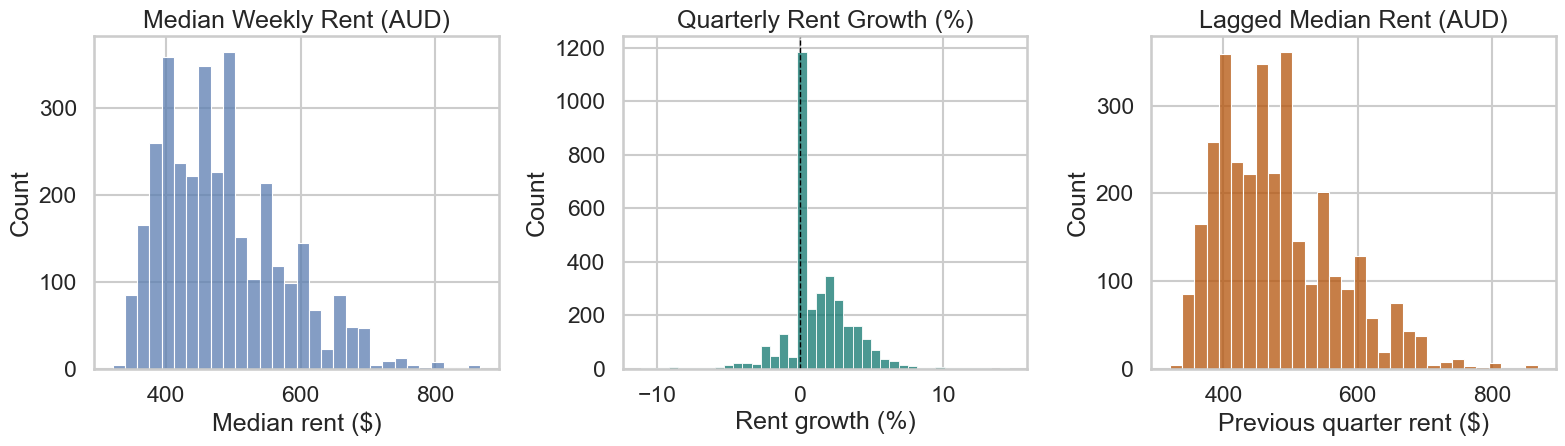

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.histplot(df["median_rent"].dropna(), bins=30, color="#5B7DB1", edgecolor="white", ax=axes[0])
axes[0].set_title("Median Weekly Rent (AUD)")
axes[0].set_xlabel("Median rent ($)")
axes[0].set_ylabel("Count")

sns.histplot(df["rent_growth"].dropna(), bins=40, color="#0F766E", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Quarterly Rent Growth (%)")
axes[1].set_xlabel("Rent growth (%)")
axes[1].set_ylabel("Count")

sns.histplot(df["lag_median_rent"].dropna(), bins=30, color="#B45309", edgecolor="white", ax=axes[2])
axes[2].set_title("Lagged Median Rent (AUD)")
axes[2].set_xlabel("Previous quarter rent ($)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Distributions

**Median rent** is right-skewed with a peak around \$350–\$450 per week. Most suburbs cluster in the \$300–\$500 range, with a long right tail extending past \$800. This reflects Melbourne's housing market structure: many middle-ring and outer suburbs with moderate rents, and a smaller number of premium inner-city areas.

**Rent growth** is approximately symmetric and centred slightly above zero. The distribution is roughly bell-shaped, suggesting that most suburb-quarters see small rent changes (±2%), with more extreme movements being rarer. The slight right lean confirms net positive rent growth over the period. There is notable bunching around zero — many suburb-quarters show exactly 0% growth, which could reflect sticky rent-setting or rounding in the underlying data.

**Lagged median rent** mirrors the current rent distribution (as expected, since it is just the prior quarter's value).

## 3. Rent Dynamics Over Time

Since this is panel data with a time dimension, we examine how rents and rent growth have evolved across the sample period. This is crucial for identifying structural breaks (e.g. COVID-19) that may affect modelling.

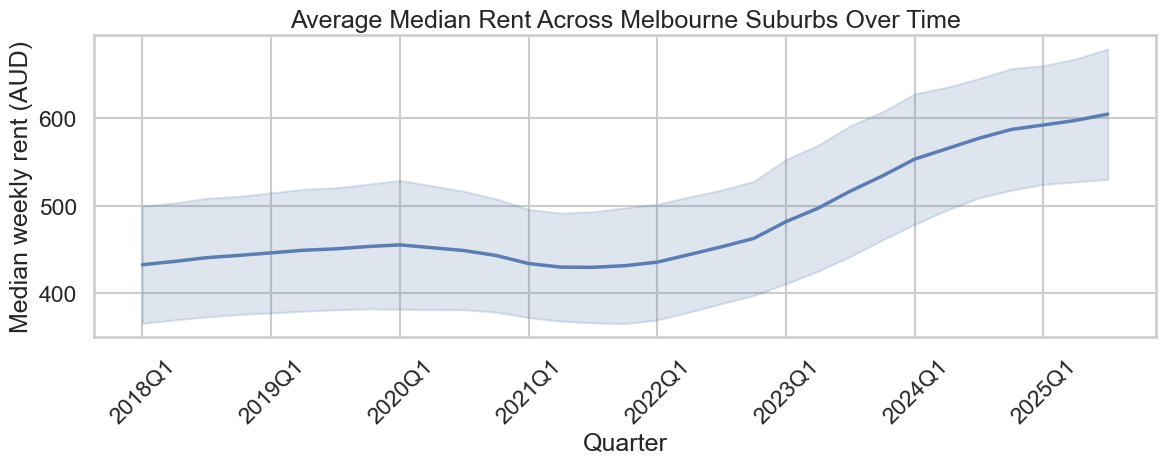

In [7]:
# Compute mean and std of rent across suburbs for each quarter
time_stats = df.groupby("quarter")["median_rent"].agg(["mean", "std"]).reset_index()
time_stats.columns = ["quarter", "mean_rent", "std_rent"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_stats["quarter"], time_stats["mean_rent"], color="#5B7DB1", linewidth=2.5)
ax.fill_between(
    time_stats["quarter"],
    time_stats["mean_rent"] - time_stats["std_rent"],
    time_stats["mean_rent"] + time_stats["std_rent"],
    alpha=0.2, color="#5B7DB1"
)
ax.set_title("Average Median Rent Across Melbourne Suburbs Over Time")
ax.set_xlabel("Quarter")
ax.set_ylabel("Median weekly rent (AUD)")
ax.set_xticks(time_stats["quarter"][::4])  # label every 4th quarter (yearly)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../outputs/rent_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

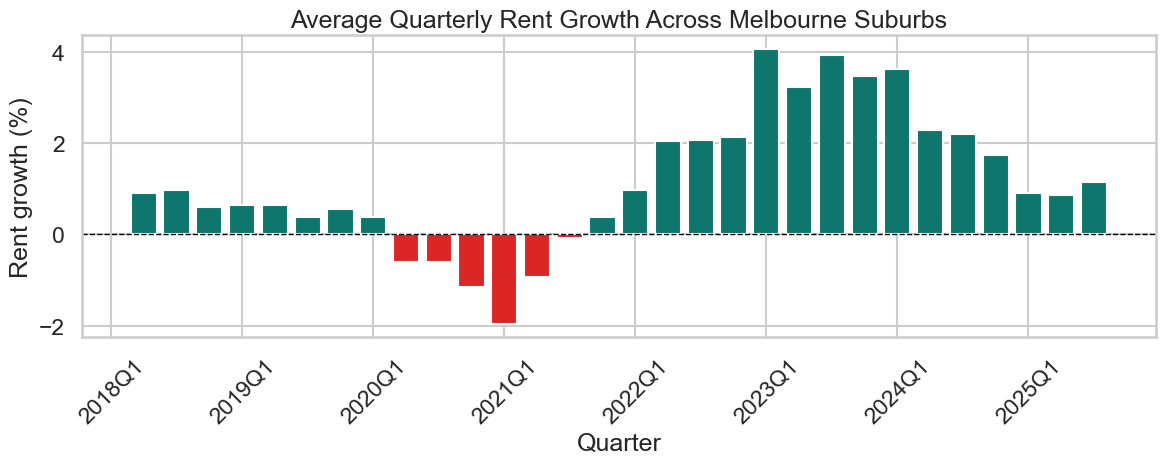

In [8]:
# Average rent growth by quarter
growth_by_q = df.groupby("quarter")["rent_growth"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#0F766E" if g >= 0 else "#DC2626" for g in growth_by_q["rent_growth"]]
ax.bar(growth_by_q["quarter"], growth_by_q["rent_growth"], color=colors, edgecolor="white")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Average Quarterly Rent Growth Across Melbourne Suburbs")
ax.set_xlabel("Quarter")
ax.set_ylabel("Rent growth (%)")
ax.set_xticks(growth_by_q["quarter"][::4])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../outputs/rent_growth_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Time Trends

**Rent levels** show a clear structural break around 2020–2021 corresponding to the COVID-19 pandemic. Average rents were rising steadily before the pandemic, dropped during Melbourne's extended lockdowns (2020 Q2 – 2021 Q2), and then rebounded sharply from 2022 onward. By 2024–2025, average rents have risen well above pre-pandemic levels.

**Rent growth** makes this pattern even more visible: the bar chart shows negative average growth during 2020–2021 (rents falling across most suburbs), followed by consistently positive and elevated growth from 2022 onward. The post-pandemic rent surge is a key feature of this dataset.

**Implications for modelling:** The COVID shock creates a natural experiment in the data — a large, temporary fall in rents followed by rapid recovery. Any panel regression should account for this time variation through quarter fixed effects. The shaded band in the rent level chart shows the cross-suburb standard deviation remains roughly constant over time, suggesting the spread of rents across suburbs is fairly stable even as the level shifts.

## 4. Regional Composition

Melbourne's 110 suburbs are grouped into 9 regions. We check whether the panel is balanced across regions, and whether rent levels and growth vary systematically by region.

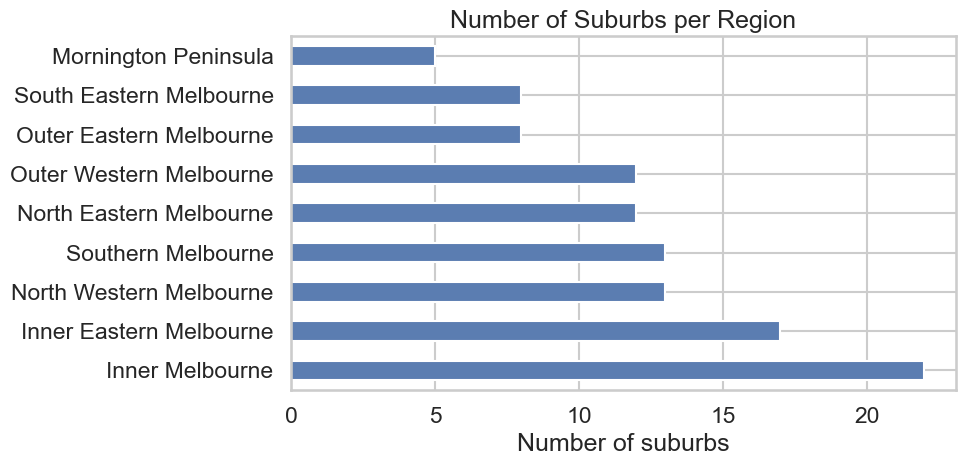

In [9]:
# Number of suburbs per region
suburbs_per_region = df.groupby("region")["suburb"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
suburbs_per_region.plot(kind="barh", color="#5B7DB1", edgecolor="white", ax=ax)
ax.set_title("Number of Suburbs per Region")
ax.set_xlabel("Number of suburbs")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

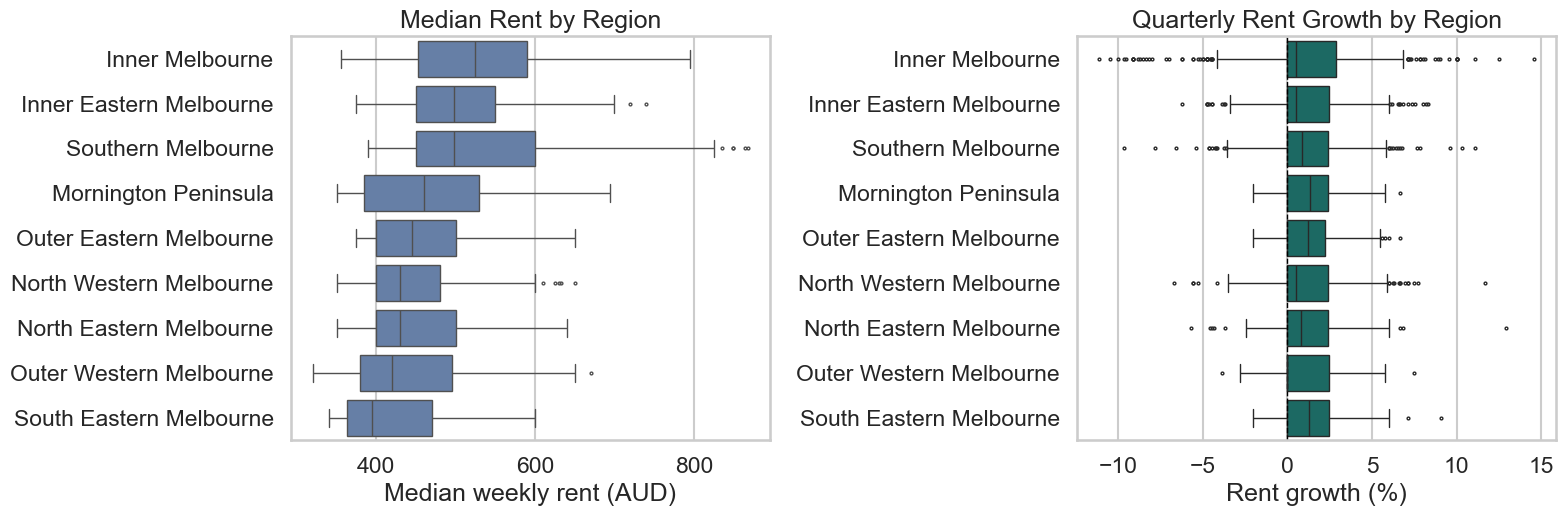

In [10]:
# Rent levels by region
order = df.groupby("region")["median_rent"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.boxplot(data=df, y="region", x="median_rent", order=order,
            color="#5B7DB1", fliersize=2, ax=axes[0])
axes[0].set_title("Median Rent by Region")
axes[0].set_xlabel("Median weekly rent (AUD)")
axes[0].set_ylabel("")

sns.boxplot(data=df.dropna(subset=["rent_growth"]), y="region", x="rent_growth", order=order,
            color="#0F766E", fliersize=2, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Quarterly Rent Growth by Region")
axes[1].set_xlabel("Rent growth (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/regional_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Regional Patterns

**Rent levels vary substantially by region.** Inner Melbourne has the highest median rents (around \$500–\$600/week), while outer regions like Mornington Peninsula and Outer Western Melbourne have lower rents (around \$300–\$400/week). This reflects expected spatial patterns — proximity to the CBD commands a rent premium.

**Rent growth is more uniform across regions**, though Inner Melbourne shows wider dispersion (more outliers in both directions). This is consistent with inner-city rents being more sensitive to demand shocks — they fell harder during COVID and recovered faster.

**The panel is not perfectly balanced across regions** — some regions have more suburbs than others. This is a feature of the underlying geography, not a data problem, but it means region fixed effects in a regression will absorb different amounts of variation. The suburb fixed effects approach in the research design naturally handles this.

## 5. Bivariate Analysis — Rent Levels and Rent Growth

Without vacancy data, we examine the relationship between rent *levels* and subsequent rent *growth*. This is relevant to the research design: if high-rent suburbs systematically grow faster (or slower), that pattern must be accounted for in the regression.

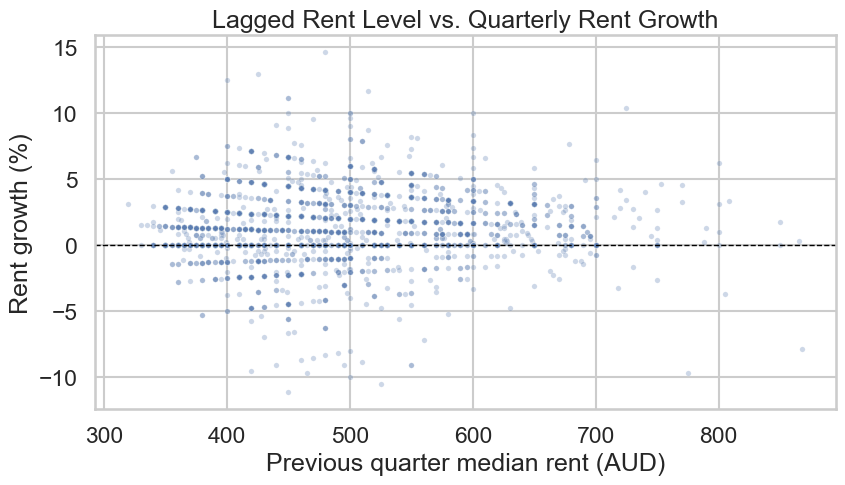

In [11]:
# Scatter plot: lagged rent vs rent growth
plot_df = df.dropna(subset=["lag_median_rent", "rent_growth"])

fig, ax = plt.subplots(figsize=(8.8, 5.2))
sns.scatterplot(data=plot_df, x="lag_median_rent", y="rent_growth",
                alpha=0.3, s=15, color="#5B7DB1", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Lagged Rent Level vs. Quarterly Rent Growth")
ax.set_xlabel("Previous quarter median rent (AUD)")
ax.set_ylabel("Rent growth (%)")
plt.tight_layout()
plt.savefig("../outputs/scatter_rent_vs_growth.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Pearson and Spearman correlation
pearson = plot_df["lag_median_rent"].corr(plot_df["rent_growth"], method="pearson")
spearman = plot_df["lag_median_rent"].corr(plot_df["rent_growth"], method="spearman")

print(f"Pearson correlation:  {pearson:.3f}")
print(f"Spearman correlation: {spearman:.3f}")

Pearson correlation:  0.081
Spearman correlation: 0.127


### Interpretation — Rent Level vs. Rent Growth

The scatter plot shows a weak relationship between the previous quarter's rent level and current rent growth. The correlation coefficients (both Pearson and Spearman) are close to zero, suggesting that knowing a suburb's rent level tells us very little about whether its rent will grow or shrink in the next quarter.

This is actually a useful finding: it means rent growth is not simply driven by whether a suburb is cheap or expensive. There is no strong evidence of mechanical mean reversion (cheap suburbs catching up) or momentum (expensive suburbs pulling further ahead) at the quarterly frequency. This supports the research hypothesis that *other* factors — like vacancy rates — may be the more important drivers of short-run rent dynamics.

The cloud of points does suggest **heteroscedasticity**: cheaper suburbs (left side) seem to show more dispersed growth rates than expensive suburbs. This could warrant using robust standard errors in the regression.

## 6. Correlation by Region

We check whether the rent level–growth relationship changes when we condition on region, guarding against Simpson's paradox.

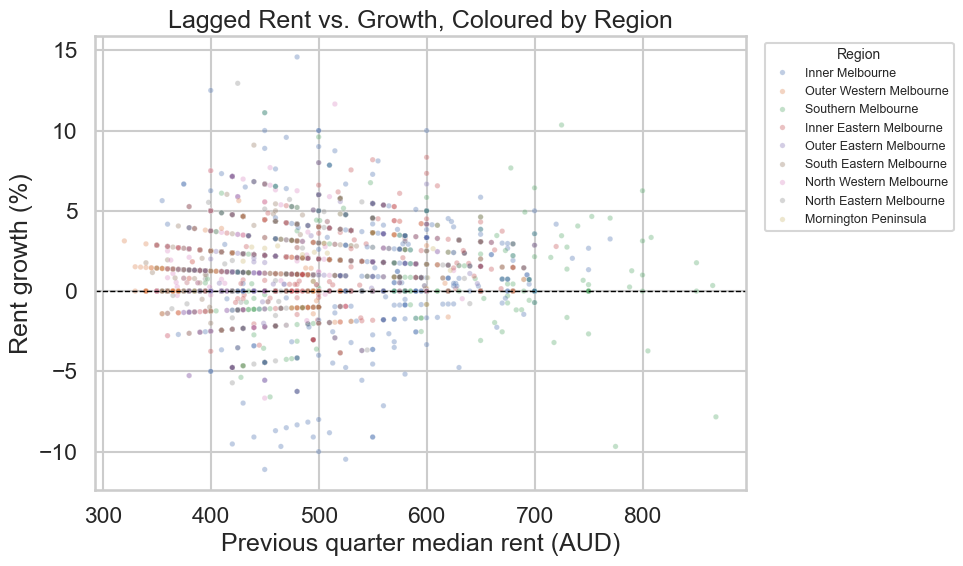

In [13]:
# Scatter coloured by region
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="lag_median_rent", y="rent_growth",
                hue="region", alpha=0.35, s=15, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Lagged Rent vs. Growth, Coloured by Region")
ax.set_xlabel("Previous quarter median rent (AUD)")
ax.set_ylabel("Rent growth (%)")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Correlation within each region
corr_by_region = (
    plot_df.groupby("region")
    .apply(lambda g: pd.Series({
        "pearson": g["lag_median_rent"].corr(g["rent_growth"], method="pearson"),
        "spearman": g["lag_median_rent"].corr(g["rent_growth"], method="spearman"),
        "n": len(g)
    }))
    .round(3)
)
corr_by_region["n"] = corr_by_region["n"].astype(int)
print("Correlation between lagged rent and rent growth, by region:")
corr_by_region

Correlation between lagged rent and rent growth, by region:


,pearson,spearman,n
region,,,
Inner Eastern Melbourne,0.189,0.223,510
Inner Melbourne,0.044,0.074,660
Mornington Peninsula,0.120,0.199,150
North Eastern Melbourne,0.154,0.185,360
North Western Melbourne,0.154,0.173,390
Outer Eastern Melbourne,0.328,0.355,240
Outer Western Melbourne,0.117,0.124,360
South Eastern Melbourne,0.345,0.456,240
Southern Melbourne,0.018,0.068,390


### Interpretation — Regional Subgroup Analysis

Breaking the relationship down by region confirms that the weak overall correlation is not masking a strong within-region pattern. The correlations remain small across all regions.

The coloured scatter plot shows that regions occupy distinct horizontal bands (reflecting their different rent levels), but within each band the growth rates are similarly dispersed. This is further evidence that rent *levels* and rent *growth* are largely orthogonal, and that the interesting variation in growth likely comes from time-varying factors (like vacancy rates or economic shocks) rather than the cross-sectional rent level.

**No Simpson's paradox is present here** — the weak pooled relationship is also weak within subgroups.

## 7. Log Scale — Rent Level Distribution

Given the right-skewness observed in the rent distribution, we check whether a log transformation normalises it. If so, modelling log-rents or log-growth may be preferable.

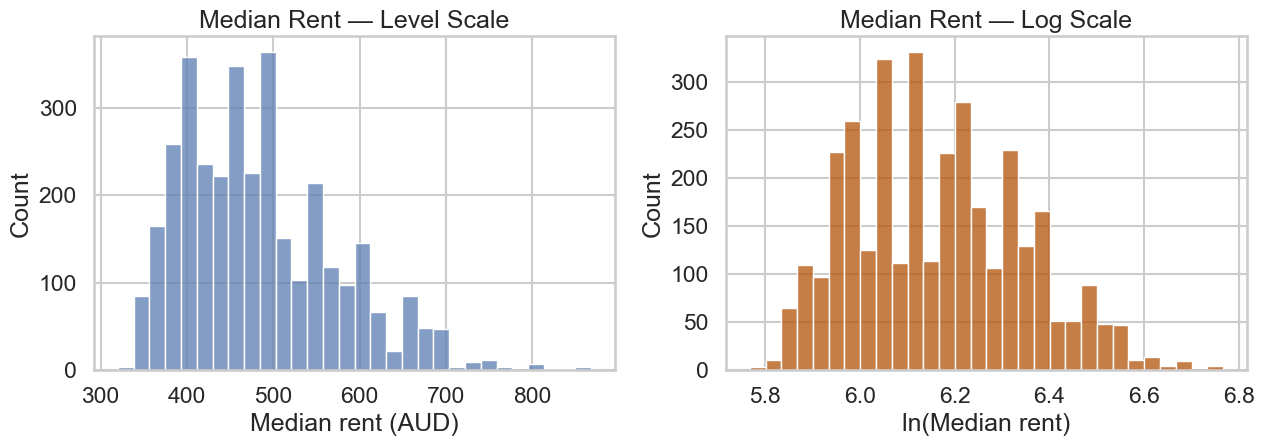

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(df["median_rent"].dropna(), bins=30, color="#5B7DB1", edgecolor="white", ax=axes[0])
axes[0].set_title("Median Rent — Level Scale")
axes[0].set_xlabel("Median rent (AUD)")

sns.histplot(np.log(df["median_rent"].dropna()), bins=30, color="#B45309", edgecolor="white", ax=axes[1])
axes[1].set_title("Median Rent — Log Scale")
axes[1].set_xlabel("ln(Median rent)")

plt.tight_layout()
plt.savefig("../outputs/log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Log Transformation

The log-transformed rent distribution is noticeably more symmetric than the raw distribution. The right tail of expensive suburbs is pulled in, producing a shape closer to a normal distribution.

**Modelling implication:** Using log-rent as the dependent variable in the panel regression may be preferable. Percentage changes in rent (which is what `rent_growth` already captures) are the natural unit for a log-level model. This also means the regression coefficients would have a percentage-change interpretation, which is economically intuitive.

## 8. Summary and Modelling Considerations

### Key findings from EDA

1. **Rent distributions are right-skewed** — a log transformation produces a more symmetric distribution, suggesting log-rent may be a better dependent variable.

2. **COVID-19 created a major structural break** — rents fell sharply in 2020–2021 and rebounded from 2022 onward. Quarter fixed effects are essential to absorb this common time variation.

3. **Rent levels vary substantially across regions** (Inner Melbourne ≈ $500–600/wk vs. outer suburbs ≈ $300–400/wk), but rent *growth* is more uniform. Suburb fixed effects will absorb these level differences.

4. **Rent levels do not predict rent growth** — the correlation between lagged rent and growth is near zero, both overall and within regions. No Simpson's paradox is present.

5. **Possible heteroscedasticity** — cheaper suburbs show more dispersed growth rates. Robust standard errors should be used.

### Limitations

The key explanatory variable — suburb-level rental vacancy rates from SQM Research — could not be obtained due to its proprietary nature and paid access requirements. Without it, the core research question (whether low vacancy predicts faster rent growth) cannot yet be tested. This EDA characterises the dependent variable and establishes the data structure for when vacancy data becomes available.

### Next steps

1. Obtain vacancy rate data (via SQM academic access or alternative sources such as Domain rental listings counts)
2. Merge vacancy data into the panel and repeat bivariate EDA
3. Estimate panel regression with suburb + quarter fixed effects